# 📊 Data Analyst 2 & 3 — Preprocessing & Machine Learning
## Prediksi Harga Cabai Rawit Merah (PIHPS 2022–2026)

**Alur Kerja:**
- **DA 2** → Preprocessing: Missing Value, Normalisasi, Feature Engineering, Lag Features
- **DA 3** → Machine Learning: Training, Evaluasi (MAE, RMSE, MAPE)

> Data bersumber dari hasil kerja **Data Analyst 1** (`Data_Harga_Clean.xlsx`)


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Semua library berhasil diimport")


✅ Semua library berhasil diimport


## 2. Load Data (Output dari Data Analyst 1)

In [2]:
# Load hasil cleaning dari Data Analyst 1
df = pd.read_excel('Data_Harga_Clean.xlsx')
df = df[['Tanggal', 'Harga']].sort_values('Tanggal').reset_index(drop=True)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

print(f"📦 Shape data  : {df.shape}")
print(f"📅 Periode     : {df['Tanggal'].min().date()} s/d {df['Tanggal'].max().date()}")
print(f"💰 Harga min   : Rp {df['Harga'].min():,.0f}")
print(f"💰 Harga maks  : Rp {df['Harga'].max():,.0f}")
print(f"💰 Harga rata2 : Rp {df['Harga'].mean():,.0f}")
df.head(10)


📦 Shape data  : (1145, 2)
📅 Periode     : 2022-01-03 s/d 2026-06-15
💰 Harga min   : Rp 36,800
💰 Harga maks  : Rp 121,850
💰 Harga rata2 : Rp 62,165


,Tanggal,Harga
0,2022-01-03,91250
1,2022-01-04,90850
2,2022-01-05,88900
3,2022-01-06,81650
4,2022-01-07,76250
5,2022-01-10,66600
6,2022-01-11,62200
7,2022-01-12,61050
8,2022-01-13,59400
9,2022-01-14,59200


### Visualisasi Tren Harga

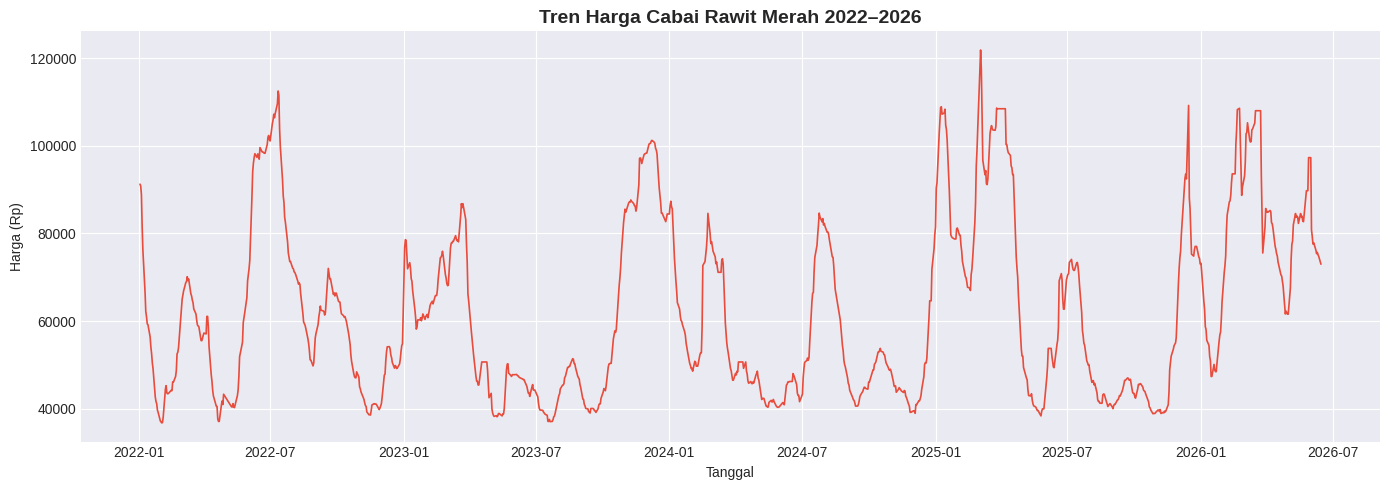

✅ Plot tren harga tersimpan


In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Tanggal'], df['Harga'], color='#e74c3c', linewidth=1.2)
plt.title('Tren Harga Cabai Rawit Merah 2022–2026', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.tight_layout()
plt.savefig('plot_tren_harga.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot tren harga tersimpan")


---
## 📌 DATA ANALYST 2 — Preprocessing

### 3. Penanganan Missing Value

In [4]:
print("=== Cek Missing Value ===")
print(df.isnull().sum())
print(f"\nTotal missing value: {df.isnull().sum().sum()}")

# Jika ada missing value, lakukan interpolasi
if df.isnull().sum().sum() > 0:
    df['Harga'] = df['Harga'].interpolate(method='linear')
    print("\n✅ Missing value ditangani dengan linear interpolation")
else:
    print("\n✅ Tidak ada missing value — data sudah bersih dari DA1")


=== Cek Missing Value ===
Tanggal    0
Harga      0
dtype: int64

Total missing value: 0

✅ Tidak ada missing value — data sudah bersih dari DA1


### 4. Feature Engineering (Ekstraksi Fitur dari Tanggal)

In [5]:
# Ekstrak fitur waktu dari kolom Tanggal
df['Day']       = df['Tanggal'].dt.day
df['Month']     = df['Tanggal'].dt.month
df['Year']      = df['Tanggal'].dt.year
df['DayOfWeek'] = df['Tanggal'].dt.dayofweek   # 0=Senin … 6=Minggu
df['Quarter']   = df['Tanggal'].dt.quarter

print("✅ Fitur tanggal berhasil dibuat:")
print(df[['Tanggal','Day','Month','Year','DayOfWeek','Quarter']].head(5))


✅ Fitur tanggal berhasil dibuat:
     Tanggal  Day  Month  Year  DayOfWeek  Quarter
0 2022-01-03    3      1  2022          0        1
1 2022-01-04    4      1  2022          1        1
2 2022-01-05    5      1  2022          2        1
3 2022-01-06    6      1  2022          3        1
4 2022-01-07    7      1  2022          4        1


### 5. Lag Features & Rolling Statistics

In [6]:
# Lag features — harga N hari sebelumnya
for lag in [1, 3, 7, 14, 30]:
    df[f'Lag_{lag}'] = df['Harga'].shift(lag)

# Rolling statistics — Moving Average & Standar Deviasi
df['MA_7']   = df['Harga'].rolling(window=7).mean()    # MA 7 hari
df['MA_30']  = df['Harga'].rolling(window=30).mean()   # MA 30 hari
df['Std_7']  = df['Harga'].rolling(window=7).std()     # Std 7 hari

# Hapus baris dengan NaN akibat lag/rolling
df_ml = df.dropna().reset_index(drop=True)

print(f"✅ Fitur lag dan rolling berhasil dibuat")
print(f"   Shape setelah dropna: {df_ml.shape}")
print(f"   Total fitur baru    : {df_ml.shape[1] - 2}")
df_ml.head(3)


✅ Fitur lag dan rolling berhasil dibuat
   Shape setelah dropna: (1115, 15)
   Total fitur baru    : 13


,Tanggal,Harga,Day,Month,Year,DayOfWeek,Quarter,Lag_1,Lag_3,Lag_7,Lag_14,Lag_30,MA_7,MA_30,Std_7
0,2022-02-15,44250,15,2,2022,1,1,44050.0,43450.0,38200.0,41700.0,91250.0,44100.000000,52378.333333,670.820393
1,2022-02-16,44150,16,2,2022,2,1,44250.0,43500.0,44550.0,41200.0,90850.0,44042.857143,50821.666667,642.539604
2,2022-02-17,46150,17,2,2022,3,1,44150.0,44050.0,45300.0,39750.0,88900.0,44164.285714,49396.666667,933.949626


### 6. Normalisasi (Min-Max Scaling)

In [7]:
FEATURES = [
    'Day', 'Month', 'Year', 'DayOfWeek', 'Quarter',
    'Lag_1', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30',
    'MA_7', 'MA_30', 'Std_7'
]
TARGET = 'Harga'

X = df_ml[FEATURES]
y = df_ml[[TARGET]]

# Scaler terpisah untuk X dan y
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).ravel()

print("✅ Normalisasi Min-Max berhasil diterapkan")
print(f"   X range setelah scaling: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"   y range setelah scaling: [{y_scaled.min():.2f}, {y_scaled.max():.2f}]")


✅ Normalisasi Min-Max berhasil diterapkan
   X range setelah scaling: [0.00, 1.00]
   y range setelah scaling: [0.00, 1.00]


---
## 📌 DATA ANALYST 3 — Machine Learning

### 7. Split Data Train / Test (80:20)

In [8]:
split_idx = int(len(df_ml) * 0.8)

X_train = X_scaled[:split_idx]
X_test  = X_scaled[split_idx:]
y_train = y_scaled[:split_idx]
y_test  = y_scaled[split_idx:]

# Simpan nilai asli y_test untuk evaluasi
y_test_original = y.values[split_idx:]

print(f"✅ Pembagian data:")
print(f"   Train : {X_train.shape[0]} data ({split_idx/len(df_ml)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]} data ({(len(df_ml)-split_idx)/len(df_ml)*100:.0f}%)")
print(f"   Periode test: {df_ml['Tanggal'].iloc[split_idx].date()} s/d {df_ml['Tanggal'].iloc[-1].date()}")


✅ Pembagian data:
   Train : 892 data (80%)
   Test  : 223 data (20%)
   Periode test: 2025-08-07 s/d 2026-06-15


### 8. Fungsi Evaluasi (MAE, RMSE, MAPE)

In [9]:
def evaluate_model(model_name, y_true, y_pred):
    """Hitung MAE, RMSE, dan MAPE"""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{'='*45}")
    print(f"  Model   : {model_name}")
    print(f"  MAE     : Rp {mae:,.2f}")
    print(f"  RMSE    : Rp {rmse:,.2f}")
    print(f"  MAPE    : {mape:.2f}%")
    print(f"{'='*45}")
    return {'Model': model_name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

results = []   # Tampung semua hasil evaluasi
predictions = {}   # Tampung prediksi tiap model
print("✅ Fungsi evaluasi siap digunakan")


✅ Fungsi evaluasi siap digunakan


### 9. Model 1 — Linear Regression

In [10]:
# Training
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediksi & inverse transform
pred_lr_scaled = lr_model.predict(X_test).reshape(-1, 1)
pred_lr = scaler_y.inverse_transform(pred_lr_scaled)

# Evaluasi
res_lr = evaluate_model('Linear Regression', y_test_original, pred_lr)
results.append(res_lr)
predictions['Linear Regression'] = pred_lr.ravel()


  Model   : Linear Regression
  MAE     : Rp 1,790.30
  RMSE    : Rp 3,178.14
  MAPE    : 2.47%


### 10. Model 2 — Random Forest Regressor

In [11]:
# Training
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prediksi & inverse transform
pred_rf_scaled = rf_model.predict(X_test).reshape(-1, 1)
pred_rf = scaler_y.inverse_transform(pred_rf_scaled)

# Evaluasi
res_rf = evaluate_model('Random Forest', y_test_original, pred_rf)
results.append(res_rf)
predictions['Random Forest'] = pred_rf.ravel()


  Model   : Random Forest
  MAE     : Rp 1,875.93
  RMSE    : Rp 3,214.32
  MAPE    : 2.58%


### 11. Model 3 — XGBoost Regressor

In [12]:
# Training
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Prediksi & inverse transform
pred_xgb_scaled = xgb_model.predict(X_test).reshape(-1, 1)
pred_xgb = scaler_y.inverse_transform(pred_xgb_scaled)

# Evaluasi
res_xgb = evaluate_model('XGBoost', y_test_original, pred_xgb)
results.append(res_xgb)
predictions['XGBoost'] = pred_xgb.ravel()


  Model   : XGBoost
  MAE     : Rp 1,896.06
  RMSE    : Rp 3,197.19
  MAPE    : 2.57%


### 12. Perbandingan Evaluasi Semua Model

In [13]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('MAPE').reset_index(drop=True)
df_results.index += 1  # Mulai dari 1

print("\n📊 TABEL PERBANDINGAN MODEL")
print(df_results.to_string(index=True))

best = df_results.iloc[0]
print(f"\n🏆 Model Terbaik: {best['Model']}")
print(f"   MAPE  = {best['MAPE']:.2f}%")
print(f"   MAE   = Rp {best['MAE']:,.2f}")
print(f"   RMSE  = Rp {best['RMSE']:,.2f}")



📊 TABEL PERBANDINGAN MODEL
               Model      MAE     RMSE  MAPE
1  Linear Regression  1790.30  3178.14  2.47
2            XGBoost  1896.06  3197.19  2.57
3      Random Forest  1875.93  3214.32  2.58

🏆 Model Terbaik: Linear Regression
   MAPE  = 2.47%
   MAE   = Rp 1,790.30
   RMSE  = Rp 3,178.14


### 13. Visualisasi: Actual vs Prediksi

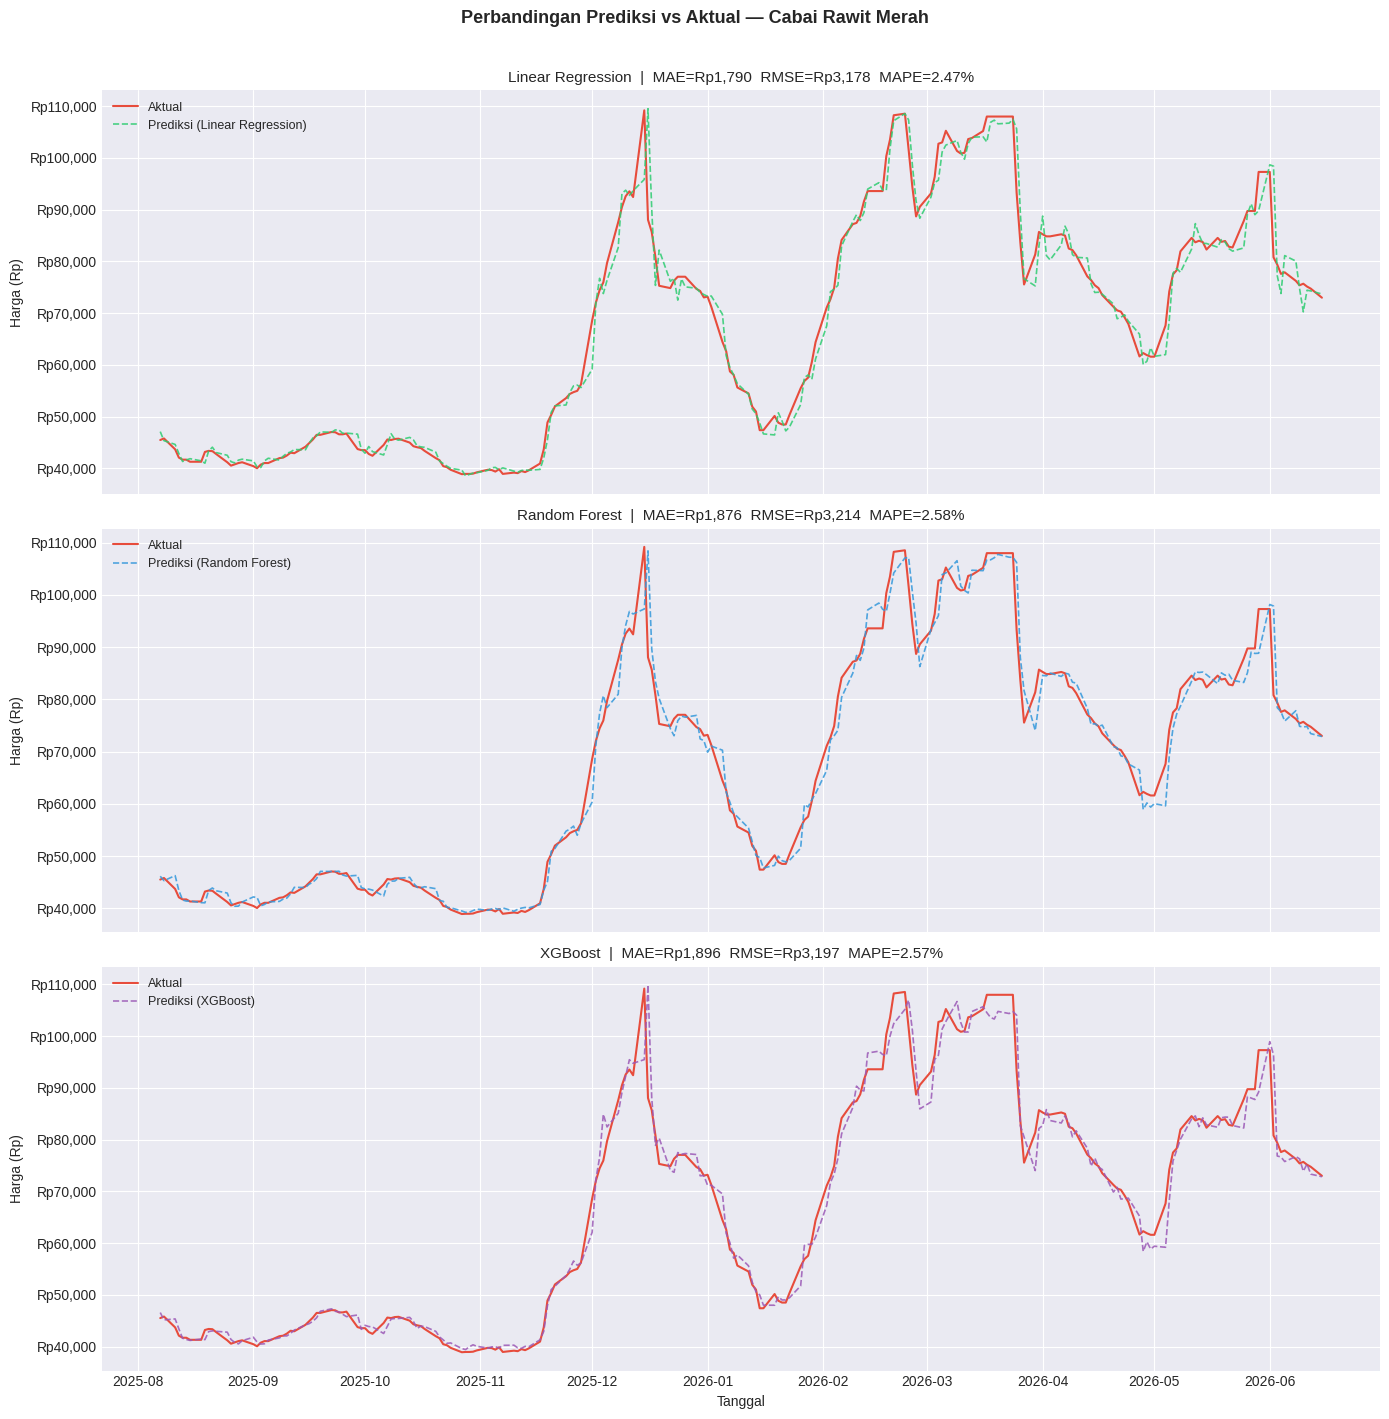

✅ Plot prediksi tersimpan


In [14]:
tanggal_test = df_ml['Tanggal'].iloc[split_idx:].values
aktual       = y_test_original.ravel()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
colors = ['#2ecc71', '#3498db', '#9b59b6']
models = ['Linear Regression', 'Random Forest', 'XGBoost']

for ax, model_name, color in zip(axes, models, colors):
    ax.plot(tanggal_test, aktual, label='Aktual', color='#e74c3c', linewidth=1.5)
    ax.plot(tanggal_test, predictions[model_name], label=f'Prediksi ({model_name})',
            color=color, linewidth=1.2, linestyle='--', alpha=0.85)
    res = next(r for r in results if r['Model'] == model_name)
    ax.set_title(f"{model_name}  |  MAE=Rp{res['MAE']:,.0f}  RMSE=Rp{res['RMSE']:,.0f}  MAPE={res['MAPE']:.2f}%",
                 fontsize=11)
    ax.set_ylabel('Harga (Rp)')
    ax.legend(loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))

axes[-1].set_xlabel('Tanggal')
fig.suptitle('Perbandingan Prediksi vs Aktual — Cabai Rawit Merah', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_prediksi_vs_aktual.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot prediksi tersimpan")


### 14. Visualisasi Perbandingan Metrik Evaluasi

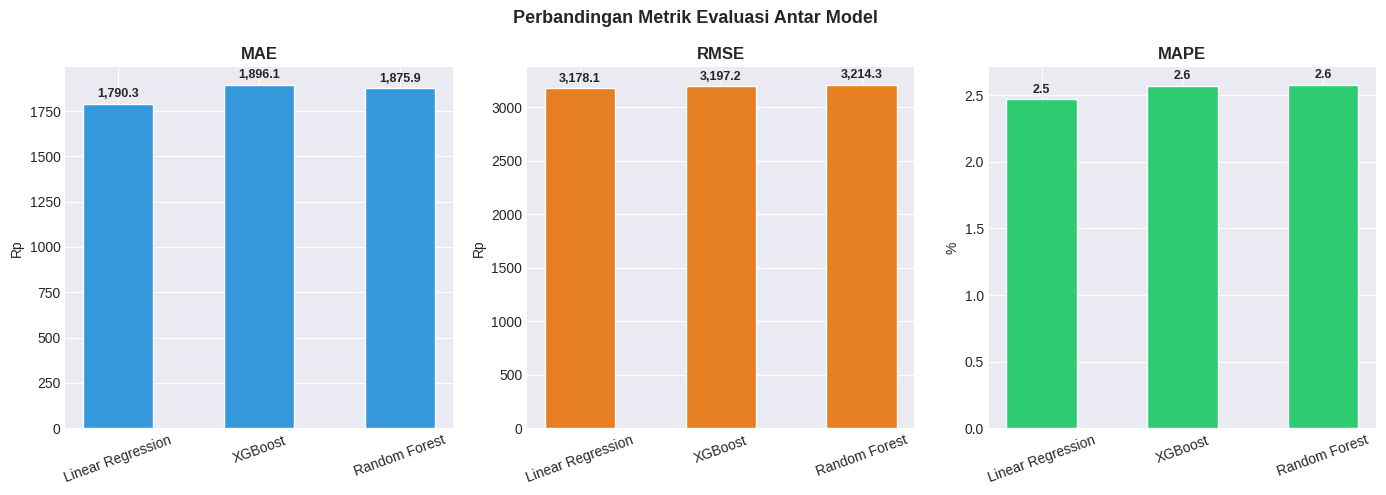

✅ Plot metrik tersimpan


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics  = ['MAE', 'RMSE', 'MAPE']
colors_bar = ['#3498db', '#e67e22', '#2ecc71']
units    = ['Rp', 'Rp', '%']

for ax, metric, color, unit in zip(axes, metrics, colors_bar, units):
    bars = ax.bar(df_results['Model'], df_results[metric], color=color, edgecolor='white', width=0.5)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(unit)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Perbandingan Metrik Evaluasi Antar Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_metrik_evaluasi.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot metrik tersimpan")


### 15. Feature Importance (Random Forest & XGBoost)

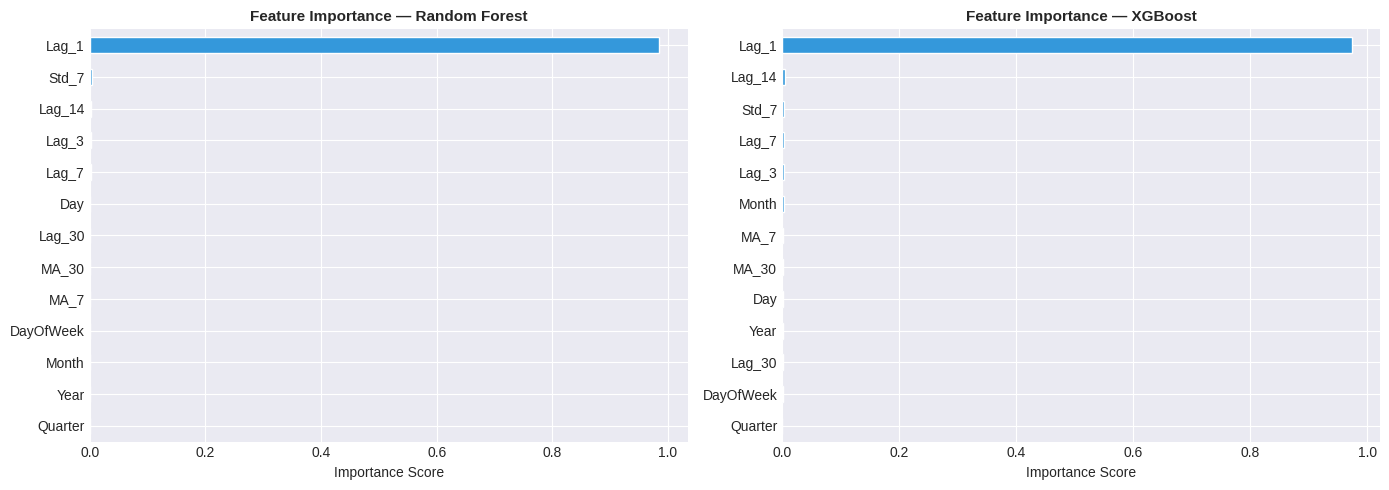

✅ Plot feature importance tersimpan


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name in zip(axes,
                            [rf_model, xgb_model],
                            ['Random Forest', 'XGBoost']):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'Feature Importance — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot feature importance tersimpan")


### 16. Kesimpulan

In [17]:
print("=" * 55)
print("       KESIMPULAN MACHINE LEARNING")
print("=" * 55)

df_results_sorted = df_results.sort_values('MAPE')
best_model = df_results_sorted.iloc[0]

print(f"\n📦 Data       : Cabai Rawit Merah (2022–2026)")
print(f"   Total data : {len(df_ml)} baris (setelah preprocessing)")
print(f"   Train      : {split_idx} data | Test: {len(df_ml)-split_idx} data")

print(f"\n📊 Hasil Evaluasi (diurutkan MAPE terbaik):")
for _, row in df_results_sorted.iterrows():
    print(f"   {row['Model']:25s} → MAE=Rp{row['MAE']:>10,.0f}  RMSE=Rp{row['RMSE']:>10,.0f}  MAPE={row['MAPE']:>5.2f}%")

print(f"\n🏆 Model Terbaik : {best_model['Model']}")
print(f"   MAPE          = {best_model['MAPE']:.2f}%  (error rata-rata per prediksi)")
print(f"   MAE           = Rp {best_model['MAE']:,.2f}")
print(f"   RMSE          = Rp {best_model['RMSE']:,.2f}")
print("=" * 55)


       KESIMPULAN MACHINE LEARNING

📦 Data       : Cabai Rawit Merah (2022–2026)
   Total data : 1115 baris (setelah preprocessing)
   Train      : 892 data | Test: 223 data

📊 Hasil Evaluasi (diurutkan MAPE terbaik):
   Linear Regression         → MAE=Rp     1,790  RMSE=Rp     3,178  MAPE= 2.47%
   XGBoost                   → MAE=Rp     1,896  RMSE=Rp     3,197  MAPE= 2.57%
   Random Forest             → MAE=Rp     1,876  RMSE=Rp     3,214  MAPE= 2.58%

🏆 Model Terbaik : Linear Regression
   MAPE          = 2.47%  (error rata-rata per prediksi)
   MAE           = Rp 1,790.30
   RMSE          = Rp 3,178.14
